In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [158]:
class Logistic_Regression():
    def __init__(self, learning_rate, no_of_iteration):
        self.learning_rate = learning_rate
        self.no_of_iteration = no_of_iteration

    def fit(self, X, Y):
        self.m, self.n = X.shape

        self.w = np.zeros(self.n)
        self.b = 0

        self.X = X
        self.Y = Y

        for _ in range(self.no_of_iteration):
            self.update_weight()

    def update_weight(self):
        Y_hat = 1 / (1 + np.exp(-(np.dot(self.X, self.w) + self.b)))

        dw = (1/self.m) * np.dot(self.X.T, (Y_hat - self.Y))
        db = (1/self.m) * np.sum(Y_hat - self.Y)

        self.w -= self.learning_rate * dw
        self.b -= self.learning_rate * db

    def predict(self, X):
        Y_pred = 1 / (1 + np.exp(-(np.dot(X, self.w) + self.b)))
        return np.where(Y_pred > 0.5, 1, 0)

In [159]:
dataset=pd.read_csv("/home/loki/Developer/Ml/Regression/LogisticRegression/diabetes.csv")

In [160]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [161]:
dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [162]:
from sklearn.model_selection import train_test_split

In [163]:
X=dataset.iloc[:,:-1]
Y=dataset.iloc[:,-1]

In [164]:
Y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [165]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=2)

In [166]:
model=Logistic_Regression(learning_rate=0.001,no_of_iteration=5000)

In [167]:
model.fit(X_train,Y_train)

In [168]:
Y_test = Y_test.ravel()

/tmp/ipykernel_74729/2436707942.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  Y_test = Y_test.ravel()


In [169]:
Y_predict=model.predict(X_test)
Y_predict

array([0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1])

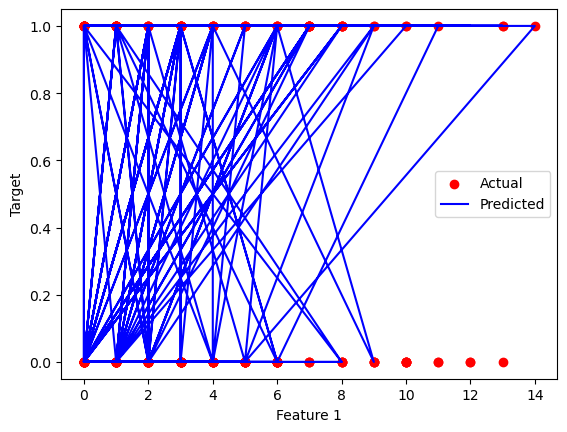

In [170]:
X_test_np = X_test.values  # Convert DataFrame to NumPy
plt.scatter(X_test_np[:, 0], Y_test, color='red', label='Actual')
plt.plot(X_test_np[:, 0], Y_predict, color='blue', label='Predicted')

plt.xlabel("Feature 1")
plt.ylabel("Target")
plt.legend()
plt.show()

In [171]:
accuracy = np.mean(Y_pred_vis == Y_test_vis)
print("Accuracy on test set:", accuracy)

Accuracy on test set: 0.35064935064935066


In [180]:
dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64